# Übung 4: Plotting und Visualisierung für die Energiewirtschaft

**Ziel:** Erstellen von Diagrammen mit Python. Pro Diagrammtyp gibt es eine Matplotlib- (statisch) und eine Plotly-Variante (interaktiv).

## 4.1 Setup und Daten laden

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots

# Saubere Defaults — einmal global, danach Plot-Code minimal halten
pio.templates.default = "plotly_white"
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"]      = True
plt.rcParams["grid.alpha"]     = 0.3
plt.rcParams["axes.axisbelow"] = True   # Grid hinter Daten

# Plotly: dezentes Grid + Null-Linie standardmäßig sichtbar
pio.templates["plotly_white"].layout.xaxis.update(zeroline=True, zerolinecolor="#888", zerolinewidth=1)
pio.templates["plotly_white"].layout.yaxis.update(zeroline=True, zerolinecolor="#888", zerolinewidth=1)

# Daten aus der Zeitreihen-Übung laden (oder synthetisch erzeugen)
try:
    df_last  = pd.read_csv("../3_Zeitreihen/haushaltslast_2024.csv", index_col=0, parse_dates=True)
    df_preis = pd.read_csv("../3_Zeitreihen/strompreise_2024.csv",   index_col=0, parse_dates=True)
except FileNotFoundError:
    np.random.seed(42)
    idx = pd.date_range("2024-01-01", "2024-12-31 23:00", freq="h")
    n = len(idx); h = idx.hour; m = idx.month
    last_kw = (0.3 + 0.5*np.sin((h-6)*np.pi/12).clip(0)
                   + 0.4*np.sin((h-17)*np.pi/6).clip(0)
                   + np.random.normal(0, 0.15, n)).clip(0.1)
    preise = (70 + 20*np.sin((m-1)*2*np.pi/12) + 15*np.sin((h-6)*np.pi/12)
              + np.random.normal(0, 12, n))
    preise[np.random.choice(n, 150, replace=False)] = np.random.uniform(-20, -1, 150)
    df_last  = pd.DataFrame({"last_kw":       last_kw}, index=idx)
    df_preis = pd.DataFrame({"price_eur_mwh": preise},  index=idx)

df = df_last.join(df_preis)
df["kosten_eur"] = df["last_kw"] * df["price_eur_mwh"] / 1000
monate = ["Jan","Feb","Mär","Apr","Mai","Jun",
          "Jul","Aug","Sep","Okt","Nov","Dez"]
df.head(3)


,last_kw,price_eur_mwh,kosten_eur
2024-01-01 00:00:00,0.749671,40.553036,0.030401
2024-01-01 01:00:00,0.686174,58.214193,0.039945
2024-01-01 02:00:00,0.764769,64.561947,0.049375


## 4.2 Linienplot — Wochenansicht der Last

**Matplotlib (statisch)**

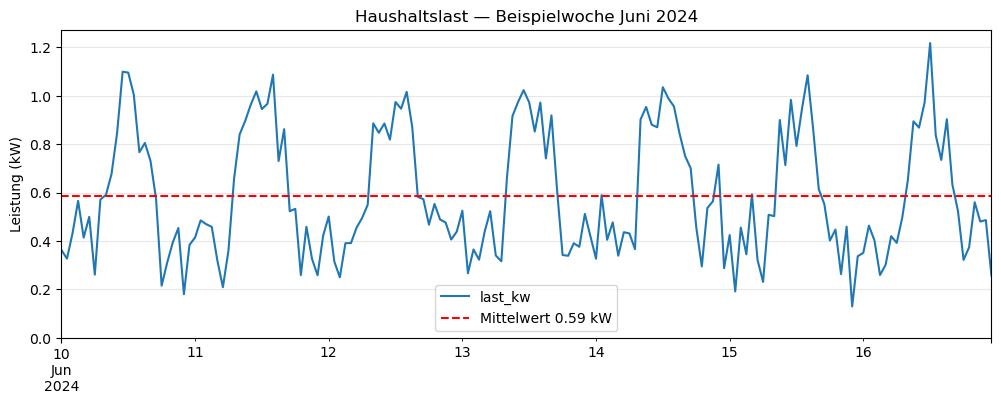

In [28]:
woche = df.loc["2024-06-10":"2024-06-16", "last_kw"]

woche.plot(title="Haushaltslast — Beispielwoche Juni 2024",
           ylabel="Leistung (kW)")
plt.axhline(woche.mean(), color="red", linestyle="--",
            label=f"Mittelwert {woche.mean():.2f} kW")
plt.ylim(bottom=0)              # Null-Linie sichtbar (Konvention bei Lastdaten)
plt.legend()
plt.show()


**Plotly (interaktiv)**

In [29]:
woche = df.loc["2024-06-10":"2024-06-16", "last_kw"]

fig = px.line(woche, title="Haushaltslast — Beispielwoche Juni 2024",
              labels={"value": "Leistung (kW)", "timestamp": ""})
fig.add_hline(y=woche.mean(), line_dash="dash", line_color="red",
              annotation_text=f"Mittelwert {woche.mean():.2f} kW")
fig.update_yaxes(rangemode="tozero")     # Null-Linie sichtbar
fig.show()


## 4.3 Linienplot mit zwei Y-Achsen — Tagesprofil

**Matplotlib (statisch)**

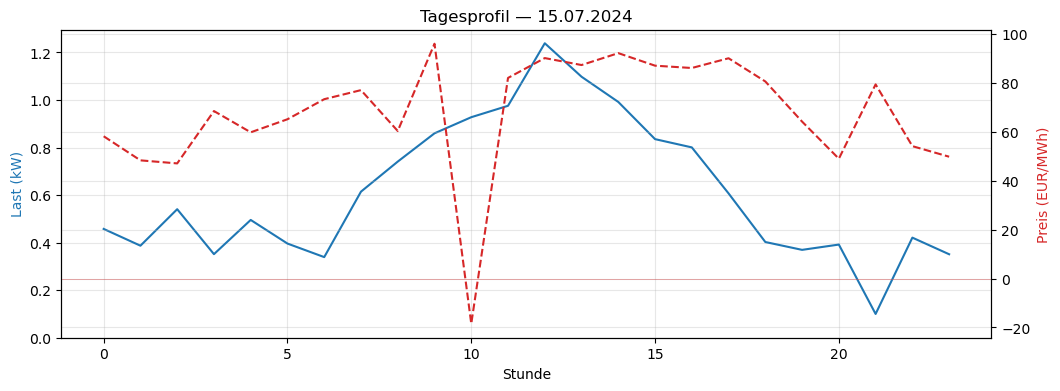

In [30]:
tag = df.loc["2024-07-15"]

fig, ax1 = plt.subplots()
ax1.plot(tag.index.hour, tag["last_kw"], color="C0", label="Last")
ax2 = ax1.twinx()
ax2.plot(tag.index.hour, tag["price_eur_mwh"], color="C3",
         linestyle="--", label="Preis")

ax1.set_xlabel("Stunde")
ax1.set_ylabel("Last (kW)",       color="C0")
ax2.set_ylabel("Preis (EUR/MWh)", color="C3")
ax1.set_ylim(bottom=0)                          # Last-Achse: Null-Linie sichtbar
ax2.axhline(0, color="C3", linewidth=0.5, alpha=0.5)  # 0-€-Linie als Referenz
plt.title("Tagesprofil — 15.07.2024")
plt.show()


**Plotly (interaktiv)**

In [31]:
tag = df.loc["2024-07-15"]

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=tag.index.hour, y=tag["last_kw"], name="Last (kW)"),
              secondary_y=False)
fig.add_trace(go.Scatter(x=tag.index.hour, y=tag["price_eur_mwh"],
                         name="Preis (EUR/MWh)", line=dict(dash="dash")),
              secondary_y=True)
fig.update_layout(title="Tagesprofil — 15.07.2024", xaxis_title="Stunde")
fig.update_yaxes(title_text="Last (kW)",       secondary_y=False, rangemode="tozero")
fig.update_yaxes(title_text="Preis (EUR/MWh)", secondary_y=True)
fig.show()


## 4.4 Balkendiagramm — Monatlicher Verbrauch

**Matplotlib (statisch)**

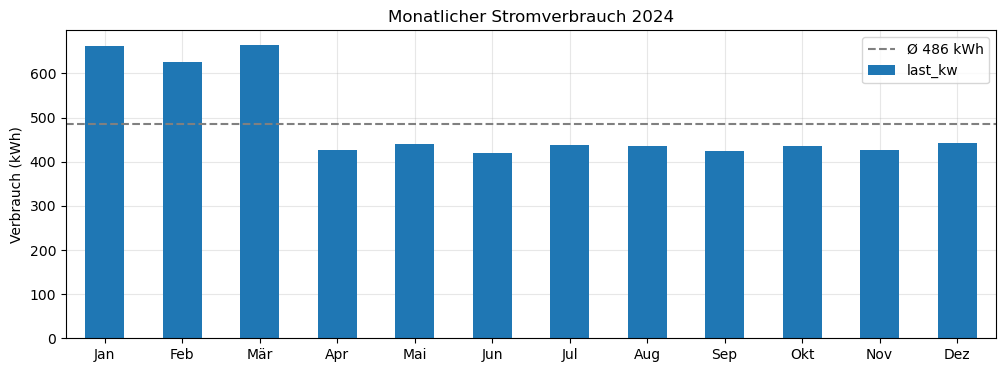

In [32]:
df_monat = df.resample("ME")["last_kw"].sum()
df_monat.index = monate

df_monat.plot(kind="bar", rot=0,
              title="Monatlicher Stromverbrauch 2024",
              ylabel="Verbrauch (kWh)")
plt.axhline(df_monat.mean(), color="gray", linestyle="--",
            label=f"Ø {df_monat.mean():.0f} kWh")
plt.legend()
plt.show()

**Plotly (interaktiv)**

In [33]:
df_monat = df.resample("ME")["last_kw"].sum()

fig = px.bar(x=monate, y=df_monat.values,
             title="Monatlicher Stromverbrauch 2024",
             labels={"x": "Monat", "y": "Verbrauch (kWh)"})
fig.add_hline(y=df_monat.mean(), line_dash="dash", line_color="gray",
              annotation_text=f"Ø {df_monat.mean():.0f} kWh")
fig.show()

## 4.5 Gestapeltes Balkendiagramm — Kostenkomponenten

**Matplotlib (statisch)**

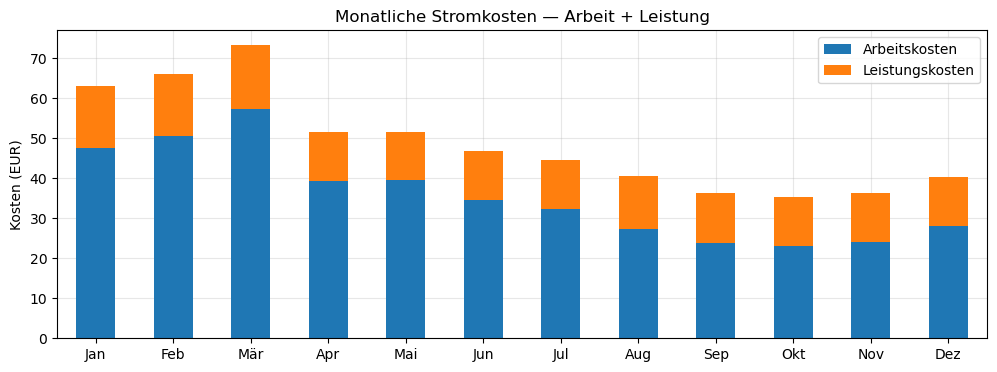

In [34]:
df["kosten_arbeit_eur"] = df["last_kw"] * df["price_eur_mwh"].clip(lower=0) / 1000

df_monat_kosten = pd.DataFrame({
    "Arbeitskosten":   df.resample("ME")["kosten_arbeit_eur"].sum().values,
    "Leistungskosten": df.resample("ME")["last_kw"].max().values * 10,  # 10 €/kW/Monat
}, index=monate)

df_monat_kosten.plot(kind="bar", stacked=True, rot=0,
                      title="Monatliche Stromkosten — Arbeit + Leistung",
                      ylabel="Kosten (EUR)")
plt.show()

**Plotly (interaktiv)**

In [35]:
fig = go.Figure()
fig.add_bar(x=monate, y=df_monat_kosten["Arbeitskosten"],   name="Arbeitskosten")
fig.add_bar(x=monate, y=df_monat_kosten["Leistungskosten"], name="Leistungskosten")
fig.update_layout(barmode="stack",
                  title="Monatliche Stromkosten — Arbeit + Leistung",
                  yaxis_title="Kosten (EUR)")
fig.show()

## 4.6 Histogramm — Preisverteilung

**Matplotlib (statisch)**

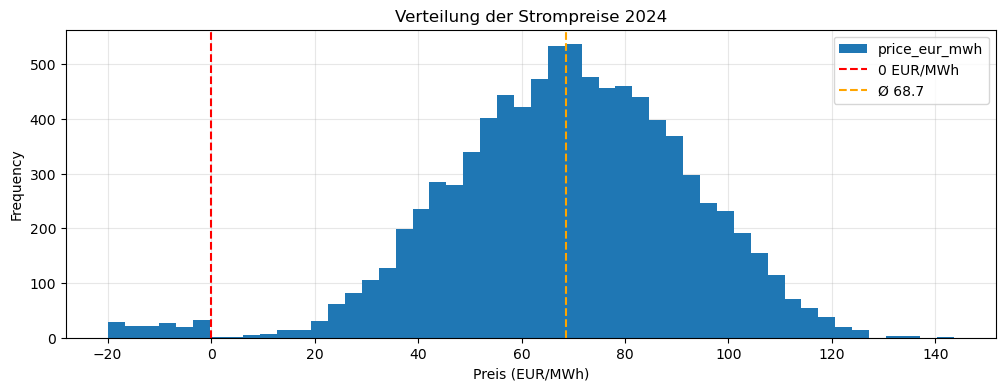

In [36]:
df["price_eur_mwh"].plot(kind="hist", bins=50,
    title="Verteilung der Strompreise 2024")
plt.axvline(0, color="red", linestyle="--", label="0 EUR/MWh")
plt.axvline(df["price_eur_mwh"].mean(), color="orange", linestyle="--",
            label=f"Ø {df['price_eur_mwh'].mean():.1f}")
plt.xlabel("Preis (EUR/MWh)")
plt.legend()
plt.show()

**Plotly (interaktiv)**

In [37]:
fig = px.histogram(df, x="price_eur_mwh", nbins=50,
                   title="Verteilung der Strompreise 2024",
                   labels={"price_eur_mwh": "Preis (EUR/MWh)"})
fig.add_vline(x=0, line_dash="dash", line_color="red",
              annotation_text="0 EUR/MWh")
fig.add_vline(x=df["price_eur_mwh"].mean(), line_dash="dash",
              line_color="orange",
              annotation_text=f"Ø {df['price_eur_mwh'].mean():.1f}")
fig.show()

## 4.7 Boxplot — Preisverteilung nach Monat

**Matplotlib (statisch)**

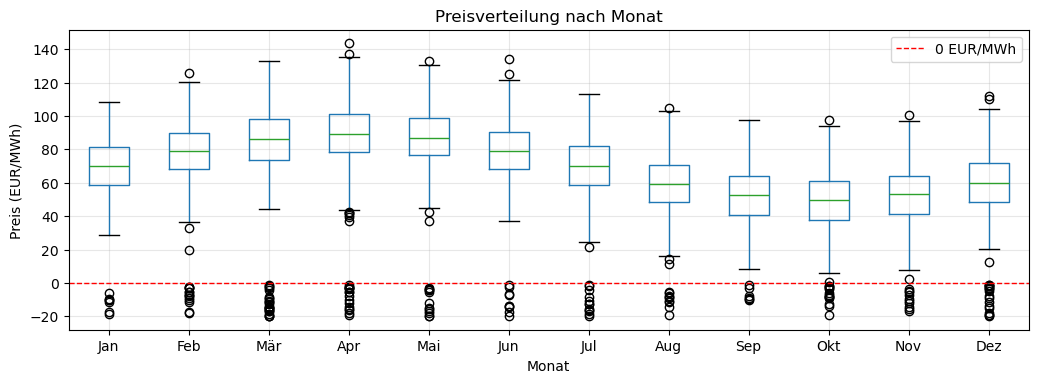

In [38]:
df_box = df.copy()
df_box["monat"] = df_box.index.month

ax = df_box.boxplot(column="price_eur_mwh", by="monat")
ax.axhline(0, color="red", linestyle="--", linewidth=1, label="0 EUR/MWh")
ax.set_xticklabels(monate)
plt.suptitle("")  # automatischer "Boxplot grouped by..." entfernen
plt.title("Preisverteilung nach Monat")
plt.xlabel("Monat"); plt.ylabel("Preis (EUR/MWh)")
plt.legend()
plt.show()

**Plotly (interaktiv)**

In [39]:
fig = px.box(df.assign(monat=df.index.month),
             x="monat", y="price_eur_mwh",
             title="Preisverteilung nach Monat",
             labels={"monat": "Monat", "price_eur_mwh": "Preis (EUR/MWh)"})
fig.add_hline(y=0, line_dash="dash", line_color="red",
              annotation_text="0 EUR/MWh")
fig.update_xaxes(tickmode="array", tickvals=list(range(1, 13)), ticktext=monate)
fig.show()

## 4.8 Heatmap — Stündliches Lastprofil

**Matplotlib (statisch)**

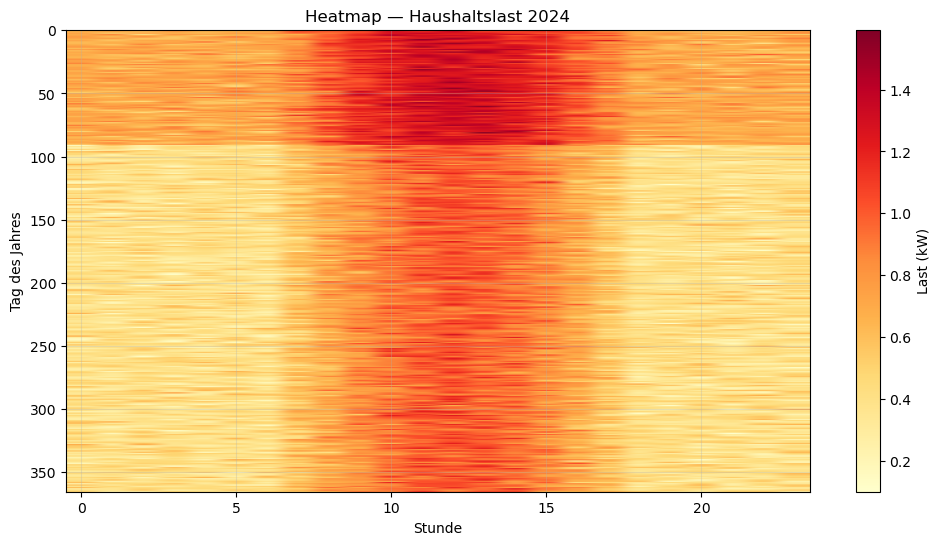

In [40]:
heatmap = df["last_kw"].groupby(
    [df.index.date, df.index.hour]).mean().unstack()

plt.figure(figsize=(12, 6))
plt.imshow(heatmap.values, aspect="auto", cmap="YlOrRd")
plt.colorbar(label="Last (kW)")
plt.title("Heatmap — Haushaltslast 2024")
plt.xlabel("Stunde"); plt.ylabel("Tag des Jahres")
plt.show()

**Plotly (interaktiv)**

In [41]:
fig = px.imshow(heatmap, aspect="auto", color_continuous_scale="YlOrRd",
                title="Heatmap — Haushaltslast 2024",
                labels=dict(x="Stunde", y="Tag", color="Last (kW)"))
fig.show()

## 4.9 Dauerlinie — Jahresdauerlinie

**Matplotlib (statisch)**

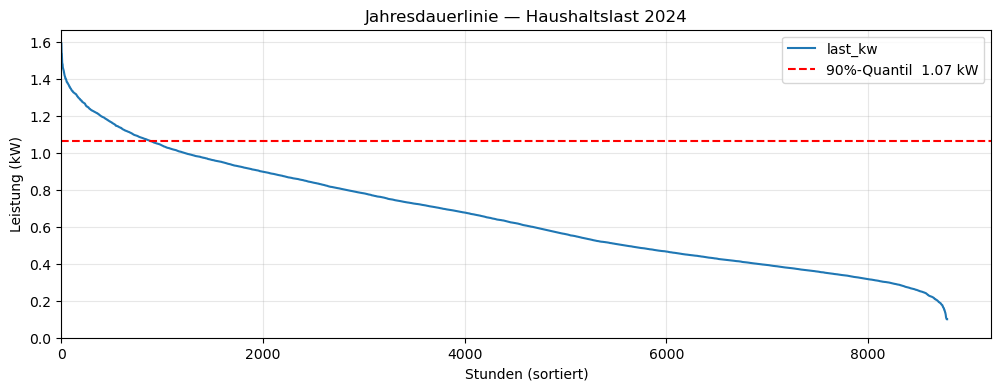

In [42]:
last_sorted = df["last_kw"].sort_values(ascending=False).reset_index(drop=True)

last_sorted.plot(title="Jahresdauerlinie — Haushaltslast 2024",
                 xlabel="Stunden (sortiert)", ylabel="Leistung (kW)")
plt.axhline(df["last_kw"].quantile(0.9), color="red", linestyle="--",
            label=f"90%-Quantil  {df['last_kw'].quantile(0.9):.2f} kW")
plt.ylim(bottom=0)              # Null-Linie sichtbar
plt.xlim(left=0)
plt.legend()
plt.show()


**Plotly (interaktiv)**

In [43]:
last_sorted = df["last_kw"].sort_values(ascending=False).reset_index(drop=True)

fig = px.line(last_sorted, title="Jahresdauerlinie — Haushaltslast 2024",
              labels={"index": "Stunden (sortiert)", "value": "Leistung (kW)"})
fig.add_hline(y=df["last_kw"].quantile(0.9), line_dash="dash",
              line_color="red",
              annotation_text=f"90%-Quantil {df['last_kw'].quantile(0.9):.2f} kW")
fig.update_yaxes(rangemode="tozero")
fig.update_xaxes(rangemode="tozero")
fig.show()


## 4.10 Tagesprofil mit Unsicherheitsband

**Matplotlib (statisch)**

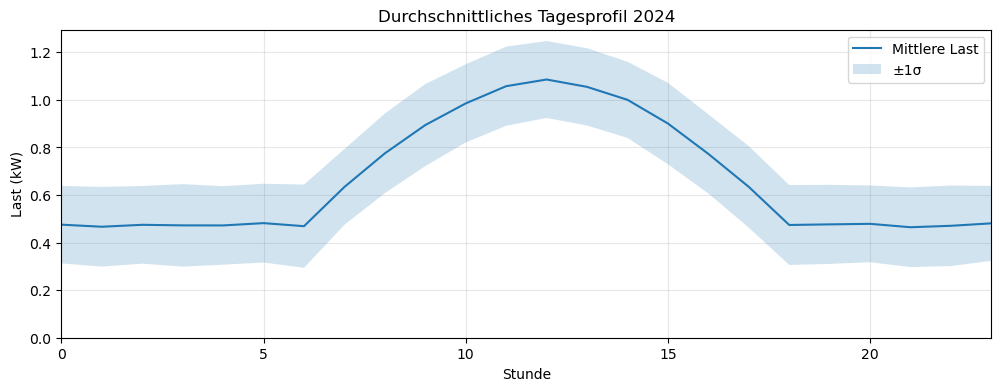

In [44]:
profil = df.groupby(df.index.hour)["last_kw"].agg(["mean", "std"])

plt.plot(profil.index, profil["mean"], label="Mittlere Last")
plt.fill_between(profil.index,
                 profil["mean"] - profil["std"],
                 profil["mean"] + profil["std"],
                 alpha=0.2, label="±1σ")
plt.title("Durchschnittliches Tagesprofil 2024")
plt.xlabel("Stunde"); plt.ylabel("Last (kW)")
plt.ylim(bottom=0)              # Null-Linie sichtbar
plt.xlim(0, 23)
plt.legend()
plt.show()


**Plotly (interaktiv)**

In [45]:
profil = df.groupby(df.index.hour)["last_kw"].agg(["mean", "std"])

fig = go.Figure([
    go.Scatter(x=profil.index, y=profil["mean"] + profil["std"],
               line=dict(width=0), showlegend=False),
    go.Scatter(x=profil.index, y=profil["mean"] - profil["std"],
               line=dict(width=0), fill="tonexty", name="±1σ"),
    go.Scatter(x=profil.index, y=profil["mean"], name="Mittlere Last"),
])
fig.update_layout(title="Durchschnittliches Tagesprofil 2024",
                  xaxis_title="Stunde", yaxis_title="Last (kW)")
fig.update_yaxes(rangemode="tozero")
fig.show()


## 4.11 Übungsaufgaben

Visualisiere die echten 15-min-Daten aus [../3_Zeitreihen/](../3_Zeitreihen/) —
einmal mit Matplotlib, einmal mit Plotly, plus eine kurze Interpretation.

- `dayahead_2025.csv` — Day-Ahead-Preise DE 2025
- `CHR11_last_15min_2025.csv` — Lastprofil Studentin


In [46]:
df_da = pd.read_csv("../3_Zeitreihen/dayahead_2025.csv",
                     parse_dates=["timestamp"], index_col="timestamp")
df_ll = pd.read_csv("../3_Zeitreihen/CHR11_last_15min_2025.csv",
                     parse_dates=["timestamp"], index_col="timestamp")

### Aufgabe 1: Preisverlauf 2025

Plotte den Verlauf der Day-Ahead-Preise 2025 und hebe negative Preise farblich hervor.

**Interpretation:** Was fällt am Preisverlauf auf? (1–2 Sätze)


**Matplotlib**

In [47]:
# Dein Code hier:


**Plotly**

In [48]:
# Dein Code hier:


*Deine Interpretation hier...*


### Aufgabe 2: Lastprofil-Heatmap

Erstelle eine Heatmap des CHR11-Lastprofils (Tage × Stunden, gemittelt über
die vier 15-min-Werte pro Stunde).

**Interpretation:** Was sagt die Heatmap über den Tagesablauf? (1–2 Sätze)


**Matplotlib**

In [49]:
# Dein Code hier:


**Plotly**

In [50]:
# Dein Code hier:


*Deine Interpretation hier...*


### Aufgabe 3: Fixtarif vs. dynamischer Tarif

Vergleiche die monatlichen Stromkosten als gruppiertes Balkendiagramm.
Aufschlag 20 ct/kWh, Energie pro 15-min-Intervall: `last_kw * 0.25`.

**Interpretation:** Welcher Tarif ist günstiger und wann lohnt sich der
dynamische? (1–2 Sätze)


**Matplotlib**

In [51]:
# Dein Code hier:


**Plotly**

In [52]:
# Dein Code hier:


*Deine Interpretation hier...*
